**Study of ML Classifiers for Intrusion Detection System Using Machine Learning**

Objective: • Analyze network intrusion data.

• Preprocess and clean the dataset.

• Train multiple machine learning classifiers.

• Compare their classification performance.

• Identify the best model for intrusion detection.


**Import Libraries and Load Dataset**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.api.types import is_numeric_dtype
import warnings
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler ,LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier , AdaBoostClassifier , VotingClassifier , GradientBoostingClassifier
from sklearn.svm import SVC , LinearSVC
from sklearn.naive_bayes import GaussianNB
from lightgbm import LGBMClassifier
from sklearn.feature_selection import RFE
import itertools
from xgboost import XGBClassifier
from tabulate import tabulate

In [2]:
train = pd.read_parquet('/content/KDDTrain.parquet')
test = pd.read_parquet('/content/KDDTest.parquet')

In [3]:
train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,classnum
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 38 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   duration                     125973 non-null  uint16  
 1   protocol_type                125973 non-null  category
 2   service                      125973 non-null  category
 3   flag                         125973 non-null  category
 4   src_bytes                    125973 non-null  int64   
 5   dst_bytes                    125973 non-null  int64   
 6   land                         125973 non-null  uint8   
 7   wrong_fragment               125973 non-null  uint8   
 8   urgent                       125973 non-null  uint8   
 9   hot                          125973 non-null  uint8   
 10  num_failed_logins            125973 non-null  uint8   
 11  num_compromised              125973 non-null  uint16  
 12  root_shell                   125973 non-null

In [5]:
train.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,num_compromised,root_shell,...,dst_host_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,classnum
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.279250,0.001342,...,182.148945,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,19.504060
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,23.942042,0.036603,...,99.206213,0.448913,0.188881,0.309128,0.112575,0.444579,0.445818,0.306396,0.319633,2.291503
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,82.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,7479.000000,1.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [6]:
train.describe(include='all')

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,classnum
count,125973.00000,125973,125973,125973,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973,125973.000000
unique,NaN,3,70,11,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23,NaN
top,NaN,tcp,http,SF,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,normal,NaN
freq,NaN,102689,40338,74945,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,67343,NaN
mean,287.14465,NaN,NaN,NaN,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,...,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,NaN,19.504060
std,2604.51531,NaN,NaN,NaN,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,...,0.448913,0.188881,0.309128,0.112575,0.444579,0.445818,0.306396,0.319633,NaN,2.291503
min,0.00000,NaN,NaN,NaN,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000
25%,0.00000,NaN,NaN,NaN,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,18.000000
50%,0.00000,NaN,NaN,NaN,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,20.000000
75%,0.00000,NaN,NaN,NaN,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,NaN,21.000000


In [7]:
train.shape

(125973, 38)

**Exploratory Data Analysis**

In [8]:
#Missing value Analysis by getting sum of null values present
train.isnull().sum()

,0
duration,0
protocol_type,0
service,0
flag,0
src_bytes,0
dst_bytes,0
land,0
wrong_fragment,0
urgent,0
hot,0


In [9]:
#Percentage of missing values
total=train.shape[0]
missing_columns=[col for col in train.columns if train[col].isnull().sum()>0]
for col in missing_columns:
  null_count=train[col].isnull().sum()
  per=(null_count/total)*100
  print(f"{col}:{null_count}({round(per,3)}%)")


In [10]:
# Checking duplicate rows
print(f"Number of duplicate rows:{train.duplicated().sum()}")

Number of duplicate rows:5843


In [11]:
print("Total Rows:", len(train))
print("Duplicate Rows:", train.duplicated().sum())

Total Rows: 125973
Duplicate Rows: 5843


In [12]:
duplicate_percentage = (train.duplicated().sum() / len(train)) * 100
print(f"Duplicate Percentage: {duplicate_percentage:.2f}%")

Duplicate Percentage: 4.64%


In [13]:
#Checking from these duplicate rows belong
duplicate_rows = train[train.duplicated()]
duplicate_rows['class'].value_counts()

,count
class,
ipsweep,2952
nmap,893
normal,838
neptune,574
smurf,440
warezclient,58
satan,55
pod,31
land,2


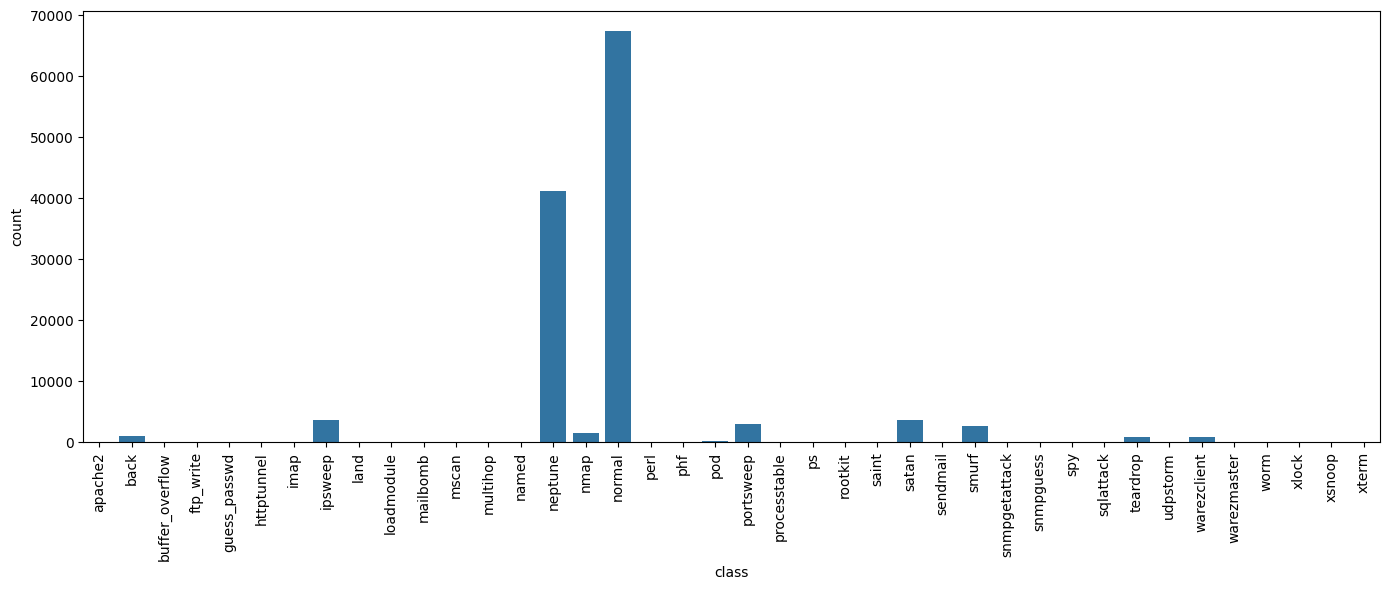

In [14]:
# Visualisation of the classes with their count
plt.figure(figsize=(14,6))
sns.countplot(x='class', data=train)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Insight:** The dataset is highly imbalanced, with 'normal' and 'neptune' classes containing the majority of records, while several attack classes have very few samples.

In [15]:
print('Class distribution training set:')
print(train['class'].value_counts())

Class distribution training set:
class
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
apache2                0
httptunnel             0
ps                     0
mscan                  0
named                  0
mailbomb               0
processtable           0
sendmail               0
saint                  0
sqlattack              0
snmpguess              0
snmpgetattack          0
udpstorm               0
worm                   0
xlock                  0
xsnoop     

**Insights:** The training dataset is highly imbalanced. The normal and neptune classes dominate the dataset, while several attack categories contain only a handful of samples.

**Comparing Train and Test Dataset**

In [16]:
print("Train Shape:", train.shape)
print("Test Shape :", test.shape)

Train Shape: (125973, 38)
Test Shape : (22544, 38)


In [17]:
train.columns.equals(test.columns)

True

In [18]:
train.dtypes.equals(test.dtypes)

True

**Feature Encoding**

In [19]:
# Encoding service, flag, protocol_type columns
categorical_cols = ['protocol_type', 'service', 'flag']
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])
    test[col] = le.transform(test[col])

    encoders[col] = le

In [20]:
train[['protocol_type', 'service', 'flag']].head()

,protocol_type,service,flag
0,1,20,9
1,2,44,9
2,1,49,5
3,1,24,9
4,1,24,9


In [21]:
train['num_outbound_cmds'].value_counts()

,count
num_outbound_cmds,
0,125973


In [22]:
print("Train classes:", train['class'].nunique())
print("Test classes :", test['class'].nunique())

Train classes: 23
Test classes : 38


In [23]:
print(set(test['class']) - set(train['class']))

{'sqlattack', 'udpstorm', 'snmpgetattack', 'saint', 'ps', 'processtable', 'xterm', 'mailbomb', 'named', 'apache2', 'xsnoop', 'xlock', 'snmpguess', 'httptunnel', 'worm', 'sendmail', 'mscan'}


In [24]:
#Encoding 'class' from both test and train
target_encoder = LabelEncoder()
all_classes = pd.concat([train['class'], test['class']])
target_encoder.fit(all_classes)
train['class'] = target_encoder.transform(train['class'])
test['class'] = target_encoder.transform(test['class'])

In [25]:
print(train['class'].nunique())
print(test['class'].nunique())

23
38


In [26]:
#Dropping this column
train = train.drop(columns=['num_outbound_cmds'])
test = test.drop(columns=['num_outbound_cmds'])

In [27]:
print('num_outbound_cmds' in train.columns)

False


**Insight:** The num_outbound_cmds feature contains only a single constant value (0) across all observations. Since it has zero variance and does not contribute to distinguishing between classes, it was removed from both the training and testing datasets.

In [28]:
#Seperating features and matrix
X_train = train.drop(columns=['class'])
y_train = train['class']

X_test = test.drop(columns=['class'])
y_test = test['class']

In [29]:
print("X_train Shape:", X_train.shape)
print("y_train Shape:", y_train.shape)

print("X_test Shape :", X_test.shape)
print("y_test Shape :", y_test.shape)

X_train Shape: (125973, 36)
y_train Shape: (125973,)
X_test Shape : (22544, 36)
y_test Shape : (22544,)


In [30]:
#removing class_num as it doesn't contribute to the target class prediction
train = train.drop(columns=['classnum'])
test = test.drop(columns=['classnum'])

In [31]:
X_train = train.drop(columns=['class'])
y_train = train['class']

X_test = test.drop(columns=['class'])
y_test = test['class']

In [32]:
print(X_train.columns)

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'num_compromised', 'root_shell', 'su_attempted',
       'num_root', 'num_file_creations', 'num_shells', 'num_access_files',
       'is_host_login', 'is_guest_login', 'count', 'serror_rate',
       'srv_serror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
       'dst_host_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
       'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
       'dst_host_serror_rate', 'dst_host_srv_serror_rate',
       'dst_host_rerror_rate', 'dst_host_srv_rerror_rate'],
      dtype='object')


**Feature Scaling**

In [33]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Insight:** Feature scaling standardizes numerical values, ensuring that distance-based algorithms such as KNN and SVM perform effectively

**Logistic Regression**

In [34]:
lr = LogisticRegression(max_iter=1000,random_state=42)
lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

**K-Nearest Neighbors (KNN)**

In [35]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [36]:
train_acc = knn.score(X_train_scaled, y_train)
test_acc = knn.score(X_test_scaled, y_test)
print("KNN Training Accuracy:", round(train_acc, 4))
print("KNN Testing Accuracy :", round(test_acc, 4))

KNN Training Accuracy: 0.9969
KNN Testing Accuracy : 0.7083


**Decision Tree Classifier**

In [37]:
dt = DecisionTreeClassifier( criterion='entropy',random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [38]:
train_acc = dt.score(X_train, y_train)
test_acc = dt.score(X_test, y_test)
print("Decision Tree Training Accuracy:", round(train_acc, 4))
print("Decision Tree Testing Accuracy :", round(test_acc, 4))

Decision Tree Training Accuracy: 0.9999
Decision Tree Testing Accuracy : 0.7034


**Random Forest Classifier**

In [39]:
# Training a random forest(This helps us understand which features contribute the most.)
rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [40]:
train_acc = rf.score(X_train, y_train)
test_acc = rf.score(X_test, y_test)

print("Random Forest Training Accuracy:", round(train_acc, 4))
print("Random Forest Testing Accuracy :", round(test_acc, 4))

Random Forest Training Accuracy: 0.9999
Random Forest Testing Accuracy : 0.7217


In [41]:
print(len(X_train.columns))
print(len(rf.feature_importances_))

35
35


In [42]:
train_accuracy = lr.score(X_train_scaled, y_train)
test_accuracy = lr.score(X_test_scaled, y_test)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy :", test_accuracy)

Training Accuracy: 0.9773919808212871
Testing Accuracy : 0.7177519517388219


In [43]:
# Random Forest Classification Report
from sklearn.metrics import classification_report
rf_pred = rf.predict(X_test)
print(classification_report(y_test, rf_pred, zero_division=0))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00       737
           1       0.93      0.98      0.95       359
           2       0.33      0.05      0.09        20
           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00      1231
           5       0.00      0.00      0.00       133
           6       0.00      0.00      0.00         1
           7       0.58      0.99      0.73       141
           8       1.00      0.14      0.25         7
           9       0.00      0.00      0.00         2
          10       0.00      0.00      0.00       293
          11       0.00      0.00      0.00       996
          12       0.00      0.00      0.00        18
          13       0.00      0.00      0.00        17
          14       0.96      1.00      0.98      4657
          15       1.00      1.00      1.00        73
          16       0.65      0.97      0.78      9711
          17       0.50    

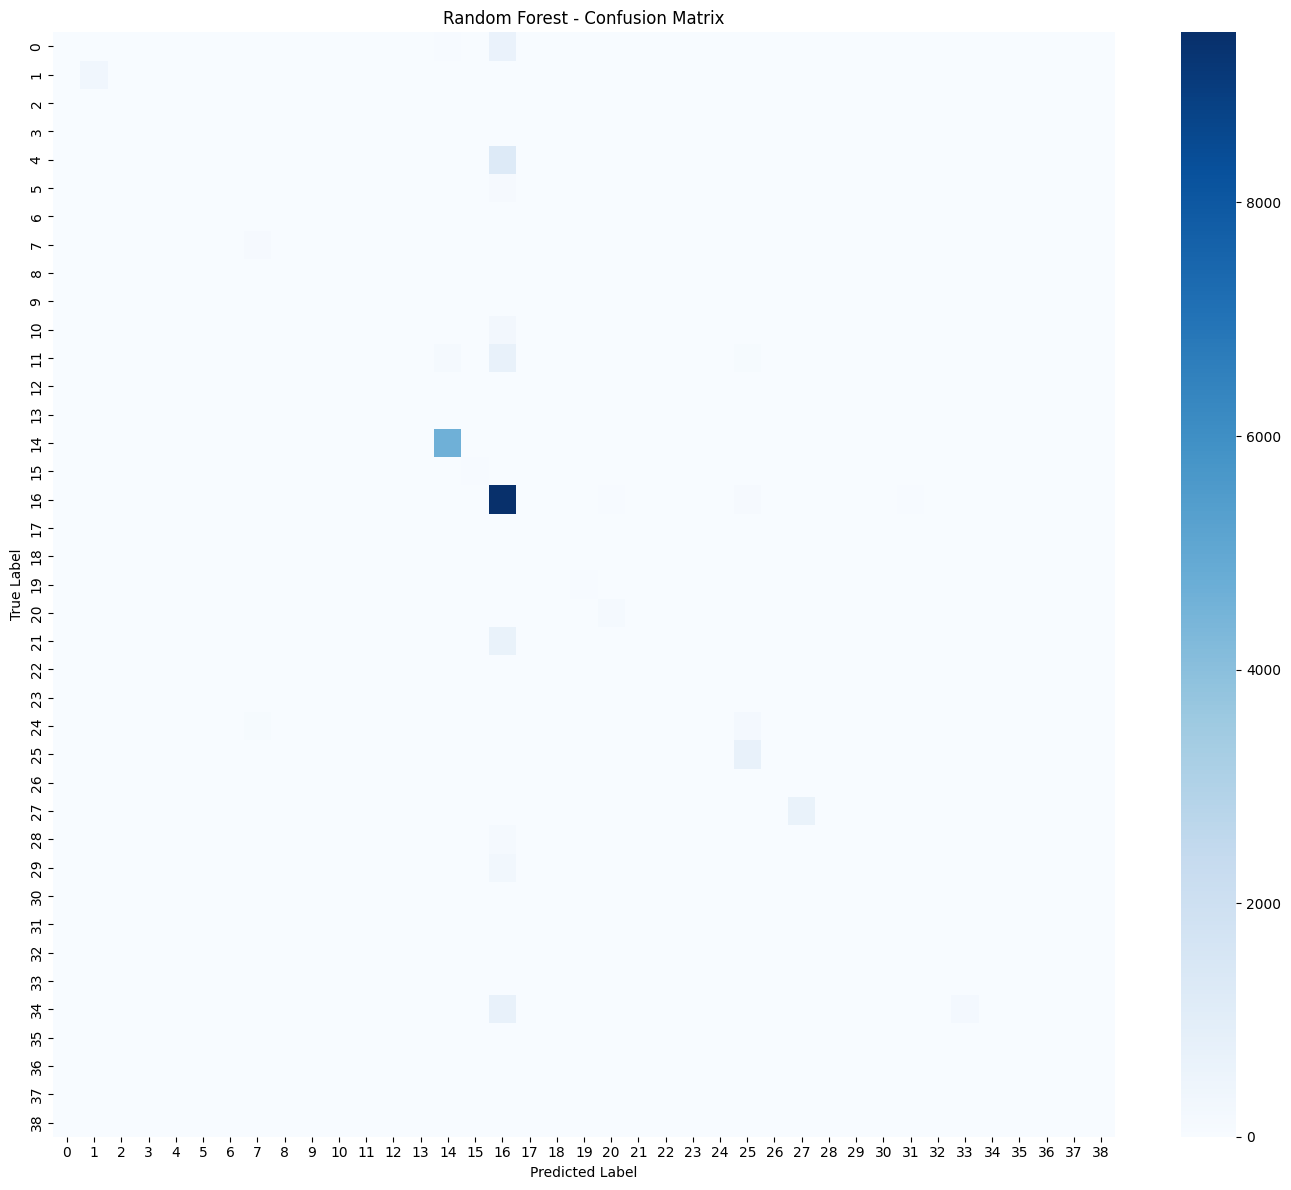

In [44]:
# Random Forest Confusion Matrix from sklearn.metrics import confusion_matrix
from sklearn.metrics import confusion_matrix
rf_pred = rf.predict(X_test)
cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap="Blues", cbar=True)
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [45]:
lr_test_accuracy = lr.score(X_test_scaled, y_test)
print(f'Logistic Regression Test Accuracy: {lr_test_accuracy:.4f}')

Logistic Regression Test Accuracy: 0.7178


**Support Vector Machine (SVM)**

In [46]:
svm = SVC(kernel='rbf',random_state=42)
svm.fit(X_train_scaled, y_train)

SVC(random_state=42)

In [47]:
train_acc = svm.score(X_train_scaled, y_train)
test_acc = svm.score(X_test_scaled, y_test)
print("SVM Training Accuracy:", round(train_acc, 4))
print("SVM Testing Accuracy :", round(test_acc, 4))


SVM Training Accuracy: 0.9903
SVM Testing Accuracy : 0.7107


**Naive Bayes**

In [48]:
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)

GaussianNB()

In [49]:
train_acc = nb.score(X_train_scaled, y_train)
test_acc = nb.score(X_test_scaled, y_test)
print("Naive Bayes Training Accuracy:", round(train_acc, 4))
print("Naive Bayes Testing Accuracy :", round(test_acc, 4))

Naive Bayes Training Accuracy: 0.4586
Naive Bayes Testing Accuracy : 0.3126


**Model Performance Comparison Table**

In [50]:
import pandas as pd
results = pd.DataFrame({
    "Model": ["Logistic Regression", "K-Nearest Neighbors", "Decision Tree","Random Forest", "Support Vector Machine",
              "Gaussian Naive Bayes" ],
    "Training Accuracy": [ 0.9774,0.9969,0.9999,0.9999,0.9903,0.4586],
    "Testing Accuracy": [ 0.7178,0.7083,0.7034,0.7217,0.7107,0.3126]})
results

,Model,Training Accuracy,Testing Accuracy
0,Logistic Regression,0.9774,0.7178
1,K-Nearest Neighbors,0.9969,0.7083
2,Decision Tree,0.9999,0.7034
3,Random Forest,0.9999,0.7217
4,Support Vector Machine,0.9903,0.7107
5,Gaussian Naive Bayes,0.4586,0.3126


**Insight:** Random Forest achieved the highest testing accuracy (72.17%), followed closely by Logistic Regression and SVM, making it the most effective classifier in this study.

In [51]:
print("Number of features in X_train:", len(X_train.columns))
print("Number of feature importances:", len(rf.feature_importances_))

Number of features in X_train: 35
Number of feature importances: 35


**Feature Importance**

                   Feature  Importance
4                src_bytes    0.118918
25           diff_srv_rate    0.103052
24           same_srv_rate    0.094445
3                     flag    0.080411
31    dst_host_serror_rate    0.068993
21             serror_rate    0.063384
5                dst_bytes    0.057618
28  dst_host_diff_srv_rate    0.044399
20                   count    0.043656
1            protocol_type    0.039518


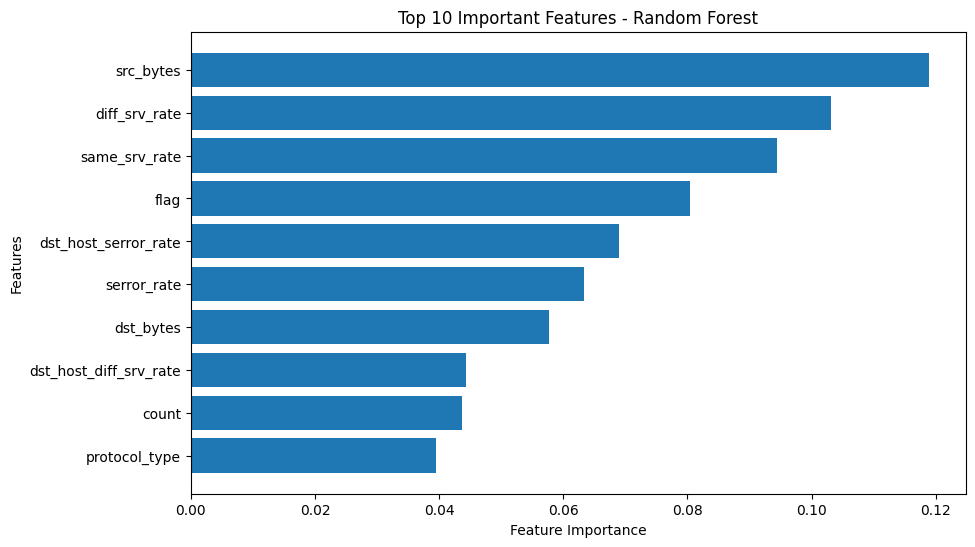

In [52]:
#Visualising important features of random forest classifier
import pandas as pd
import matplotlib.pyplot as plt

# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Display Top 10 Features
print(feature_importance.head(10))

# Plot Top 10 Features
plt.figure(figsize=(10,6))
plt.barh(
    feature_importance['Feature'][:10],
    feature_importance['Importance'][:10]
)
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features - Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.show()

**Insight:** Random Forest identified src_bytes, diff_srv_rate, same_srv_rate, flag, and dst_host_serror_rate as the most influential features for detecting network intrusions. This indicates that network traffic volume, service usage patterns, and connection error rates play a significant role in distinguishing normal traffic from malicious attacks.

## Model-wise Observations

### Logistic Regression
- Achieved 71.78% testing accuracy.
- Performed reasonably well on major attack classes.
- Struggled to classify minority attack categories.

### K-Nearest Neighbors (KNN)
- Achieved 70.83% testing accuracy.
- Very high training accuracy indicates the model memorized training patterns.
- Performance on unseen data was slightly lower than Logistic Regression.

### Decision Tree
- Achieved 70.34% testing accuracy.
- Nearly perfect training accuracy (99.99%) indicates overfitting.
- Generalization to unseen data was weaker than Random Forest.

### Random Forest
- Achieved the highest testing accuracy (72.17%).
- Reduced overfitting compared to a single Decision Tree.
- Selected as the best-performing classifier for this dataset.

### Support Vector Machine (SVM)
- Achieved 71.07% testing accuracy.
- Performed consistently but slightly below Random Forest.
- Suitable for complex decision boundaries after feature scaling.

### Gaussian Naive Bayes
- Achieved the lowest testing accuracy (31.26%).
- The independence assumption between features does not hold well for the NSL-KDD dataset.
- Therefore, it was the weakest-performing classifier.

**Performance Metrics Comparison**

In [53]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
rf_pred = rf.predict(X_test)
print("Accuracy :", round(accuracy_score(y_test, rf_pred), 4))
print("Precision:", round(precision_score(y_test, rf_pred, average='weighted', zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, rf_pred, average='weighted', zero_division=0), 4))
print("F1 Score :", round(f1_score(y_test, rf_pred, average='weighted', zero_division=0), 4))

Accuracy : 0.7217
Precision: 0.5964
Recall   : 0.7217
F1 Score : 0.6218


In [54]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    return {
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred, average='weighted', zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred, average='weighted', zero_division=0), 4),
        "F1-Score": round(f1_score(y_test, y_pred, average='weighted', zero_division=0), 4)
    }

In [55]:
results_metrics = []

results_metrics.append(evaluate_model("Logistic Regression", lr, X_test_scaled, y_test))
results_metrics.append(evaluate_model("KNN", knn, X_test_scaled, y_test))
results_metrics.append(evaluate_model("Decision Tree", dt, X_test, y_test))
results_metrics.append(evaluate_model("Random Forest", rf, X_test, y_test))
results_metrics.append(evaluate_model("SVM", svm, X_test_scaled, y_test))
results_metrics.append(evaluate_model("Gaussian Naive Bayes", nb, X_test_scaled, y_test))

In [56]:
import pandas as pd
metrics_df = pd.DataFrame(results_metrics)
metrics_df = metrics_df.sort_values(by="Accuracy", ascending=False)
metrics_df = metrics_df.reset_index(drop=True)
metrics_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.7217,0.5964,0.7217,0.6218
1,Logistic Regression,0.7178,0.5932,0.7178,0.6175
2,SVM,0.7107,0.6096,0.7107,0.6168
3,KNN,0.7083,0.6040,0.7083,0.6147
4,Decision Tree,0.7034,0.5498,0.7034,0.6075
5,Gaussian Naive Bayes,0.3126,0.3886,0.3126,0.2842


In [57]:
#Generating classification report by precision,recall,f1 score,support
from sklearn.metrics import classification_report
rf_pred = rf.predict(X_test)
print(classification_report(y_test, rf_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       737
           1       0.93      0.98      0.95       359
           2       0.33      0.05      0.09        20
           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00      1231
           5       0.00      0.00      0.00       133
           6       0.00      0.00      0.00         1
           7       0.58      0.99      0.73       141
           8       1.00      0.14      0.25         7
           9       0.00      0.00      0.00         2
          10       0.00      0.00      0.00       293
          11       0.00      0.00      0.00       996
          12       0.00      0.00      0.00        18
          13       0.00      0.00      0.00        17
          14       0.96      1.00      0.98      4657
          15       1.00      1.00      1.00        73
          16       0.65      0.97      0.78      9711
          17       0.50    

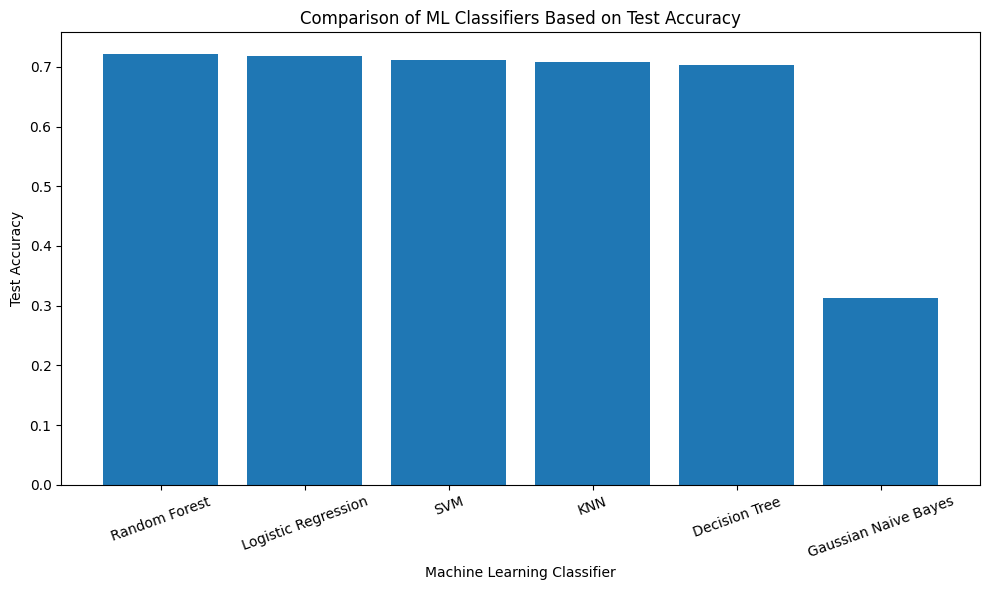

In [58]:
plt.figure(figsize=(10,6))
plt.bar(metrics_df["Model"], metrics_df["Accuracy"])
plt.title("Comparison of ML Classifiers Based on Test Accuracy")
plt.xlabel("Machine Learning Classifier")
plt.ylabel("Test Accuracy")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Conclusion**

*   Successfully developed a Machine Learning-based Intrusion Detection System (IDS) using the NSL-KDD dataset.
*   Performed data preprocessing, including label encoding, feature selection, removal of unnecessary features, and feature scaling.

*   Trained and evaluated six machine learning classifiers:

       *   Logistic Regression
       *   K-Nearest Neighbors (KNN)
       *   Decision Tree
       *   Random Forest
       *   Support Vector Machine (SVM)
       *   Gaussian Naive Bayes

*   Compared all classifiers using Accuracy, Precision, Recall, and F1-Score.
*   Random Forest achieved the highest testing accuracy (72.17%), making it the best-performing model in this study.
*   Feature importance analysis identified src_bytes, diff_srv_rate, same_srv_rate, flag, and dst_host_serror_rate as the most influential features for intrusion detection.
*   Decision Tree showed signs of overfitting due to very high training accuracy but comparatively lower testing accuracy.
*   Gaussian Naive Bayes achieved the lowest performance because the dataset does not satisfy its feature independence assumption.
*   The study demonstrates that ensemble learning methods, particularly Random Forest, are more effective for network intrusion detection than the other evaluated classifiers.

**Future Scope**


*   Improve model performance by tuning hyperparameters using GridSearchCV or RandomizedSearchCV.
*   Explore advanced ensemble algorithms such as XGBoost, LightGBM, and CatBoost for better intrusion detection.
*   Apply techniques like SMOTE to address class imbalance and improve detection of rare attack classes.
*   Perform additional feature engineering and feature selection to enhance model efficiency and accuracy.
*   Evaluate models using cross-validation for more reliable and generalized performance estimates.
*   Develop a real-time Intrusion Detection System (IDS) capable of monitoring live network traffic.
*   Deploy the trained model as a web application or integrate it with a security monitoring dashboard.
*   Investigate deep learning approaches such as ANN, CNN, or LSTM for detecting complex attack patterns.


